Loading and displaying an image

In [17]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [18]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

Task 1 - read and Display image

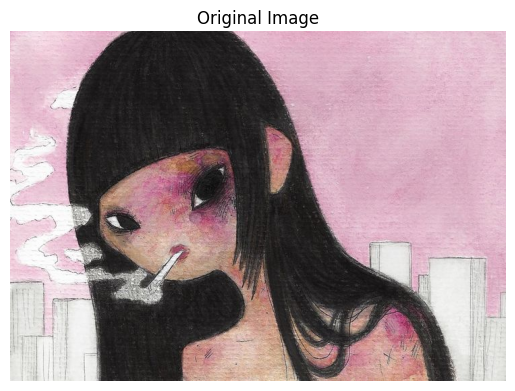

In [19]:
img = Image.open("/content/drive/My Drive/ai & ml/anita.jpg")

plt.imshow(img)
plt.title("Original Image")
plt.axis('off')
plt.show()

TASK 2 - Show Top left 100*100 Pixels

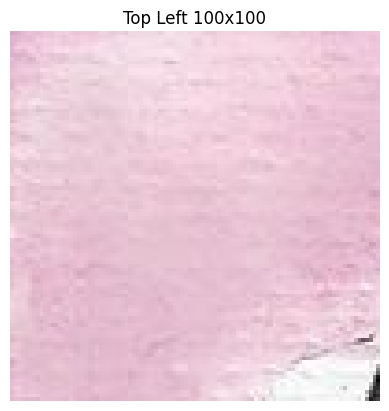

In [20]:
img_array = np.array(img)

top_left = img_array[0:100, 0:100]

plt.imshow(top_left, cmap='gray')
plt.title("Top Left 100x100")
plt.axis('off')
plt.show()

Show RGB Channels

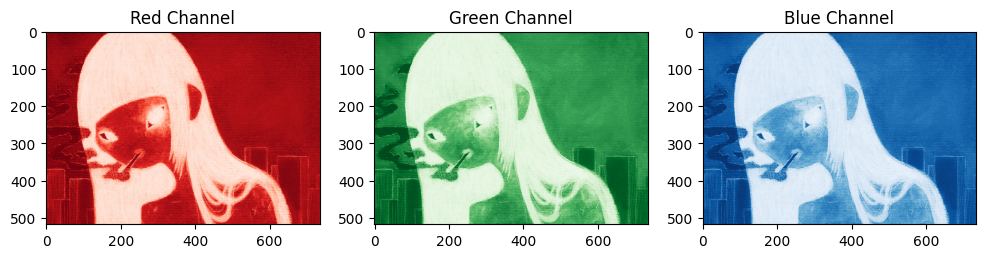

In [21]:
R = img_array[:,:,0]
G = img_array[:,:,1]
B = img_array[:,:,2]

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(R, cmap='Reds')
plt.title("Red Channel")

plt.subplot(1,3,2)
plt.imshow(G, cmap='Greens')
plt.title("Green Channel")

plt.subplot(1,3,3)
plt.imshow(B, cmap='Blues')
plt.title("Blue Channel")

plt.show()

Modify Top 100*100 Pixels

(np.float64(-0.5), np.float64(734.5), np.float64(517.5), np.float64(-0.5))

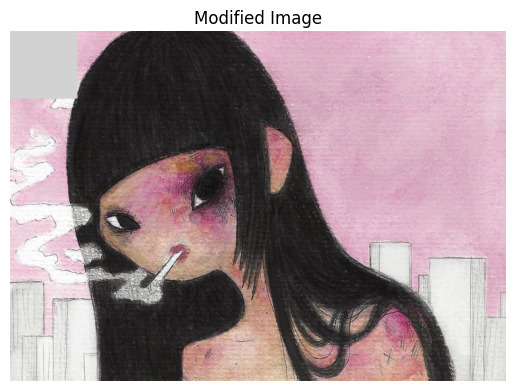

In [22]:
img_copy = img_array.copy()

img_copy[0:100,0:100] = 210

plt.imshow(img_copy)
plt.title("Modified Image")
plt.axis('off')

Exercise 2--Load Grayscale Image

(np.float64(-0.5), np.float64(735.5), np.float64(735.5), np.float64(-0.5))

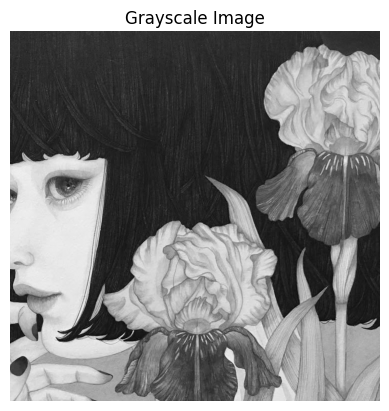

In [23]:
gray = Image.open("/content/drive/My Drive/ai & ml/anita1.jpg").convert('L')

plt.imshow(gray, cmap='gray')
plt.title("Grayscale Image")
plt.axis('off')

Crop center 150 Pixels

(np.float64(-0.5), np.float64(149.5), np.float64(149.5), np.float64(-0.5))

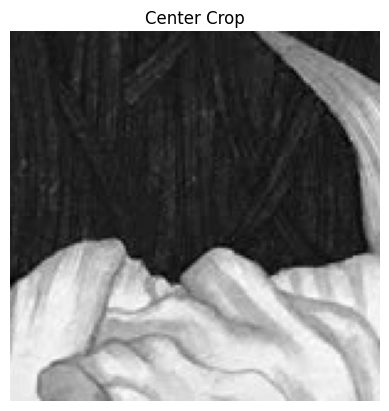

In [24]:
gray_array = np.array(gray)

h, w = gray_array.shape

center = gray_array[h//2-75:h//2+75, w//2-75:w//2+75]

plt.imshow(center, cmap='gray')
plt.title("Center Crop")
plt.axis('off')

Apply Threshold

(np.float64(-0.5), np.float64(735.5), np.float64(735.5), np.float64(-0.5))

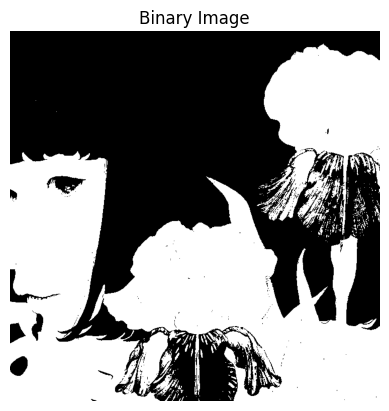

In [25]:
binary = gray_array.copy()

binary[binary < 100] = 0
binary[binary >= 100] = 255

plt.imshow(binary, cmap='gray')
plt.title("Binary Image")
plt.axis('off')

1.1 Rotate Image

(np.float64(-0.5), np.float64(735.5), np.float64(735.5), np.float64(-0.5))

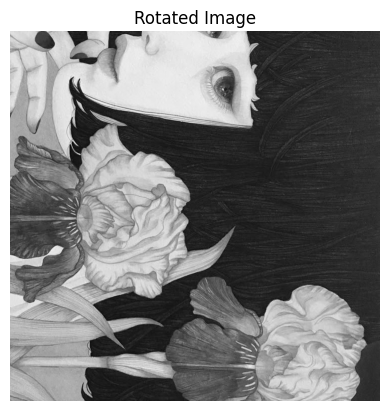

In [26]:
rotated = gray.rotate(-90)

plt.imshow(rotated, cmap='gray')
plt.title("Rotated Image")
plt.axis('off')

1.2 Convert Grayscale to RGB

(np.float64(-0.5), np.float64(735.5), np.float64(735.5), np.float64(-0.5))

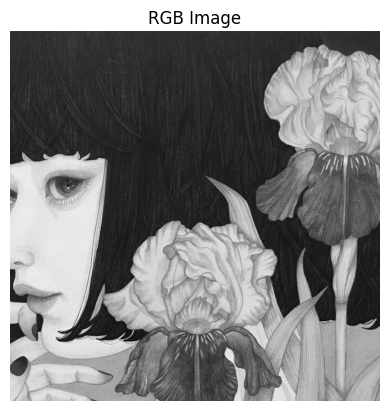

In [27]:
rgb = gray.convert('RGB')

plt.imshow(rgb)
plt.title("RGB Image")
plt.axis('off')

13 Convert Image to Matrix

(np.float64(-0.5), np.float64(735.5), np.float64(735.5), np.float64(-0.5))

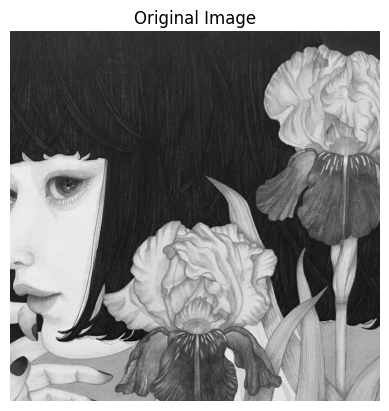

In [30]:
img = Image.open("/content/drive/My Drive/ai & ml/anita1.jpg").convert('L')
A = np.array(img)

plt.imshow(A, cmap='gray')
plt.title("Original Image")
plt.axis('off')

14 Standardize Data (Center Data)

In [31]:
mean = np.mean(A, axis=0)
A_centered = A - mean

15 Covariance matrix

In [32]:
cov = np.cov(A_centered, rowvar=False)

16 Eigenvalues and Eigenvectors

In [33]:
eigen_values, eigen_vectors = np.linalg.eig(cov)

17 Sort Eigenvalues

In [34]:
idx = np.argsort(eigen_values)[::-1]

eigen_values = eigen_values[idx]
eigen_vectors = eigen_vectors[:, idx]

18 Choose top K Components

In [35]:
k = 50

PC = eigen_vectors[:, :k]

19 Compress Image

In [37]:
compressed = np.dot(A_centered, PC)

20 Reconstruct Image

In [38]:
reconstructed = np.dot(compressed, PC.T) + mean

21 Display result

(np.float64(-0.5), np.float64(735.5), np.float64(735.5), np.float64(-0.5))

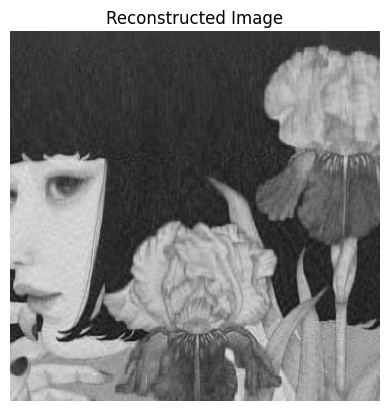

In [39]:
plt.imshow(reconstructed, cmap='gray')
plt.title("Reconstructed Image")
plt.axis('off')

22 Experiment With different k

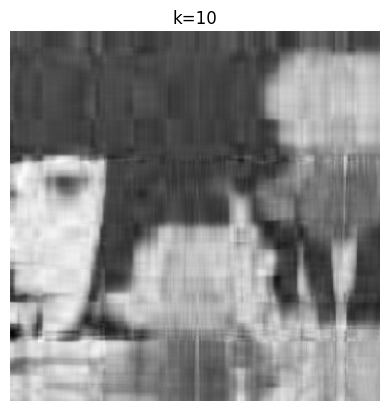

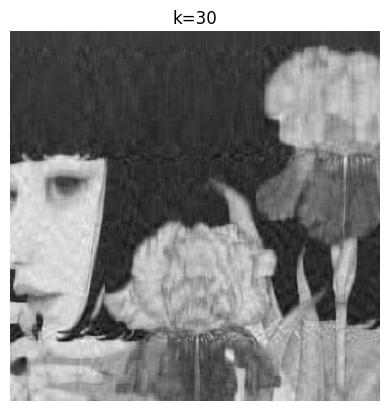

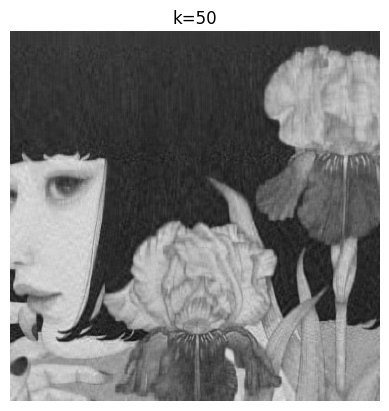

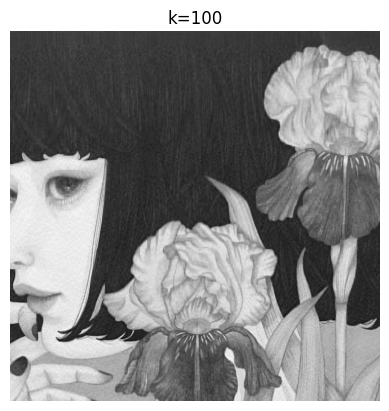

In [40]:
for k in [10,30,50,100]:

    PC = eigen_vectors[:,:k]
    compressed = np.dot(A_centered, PC)
    reconstructed = np.dot(compressed, PC.T) + mean

    plt.imshow(reconstructed, cmap='gray')
    plt.title("k="+str(k))
    plt.axis('off')
    plt.show()